# Análisis cualitativo del modelo entrenado

Este notebook carga el mejor checkpoint del modelo X3D-S (con o sin GRU) y
analiza qué está aprendiendo, dónde falla, y por qué se estanca en
val AUC ≈ 0.67.

## Estructura

1. **Setup y carga del checkpoint** — carga el mejor modelo en val_auc
2. **Inferencia sobre val** — guarda scores y atención de cada muestra
3. **Análisis 1 — Confusion matrices por escenario** — ¿hay tipos de accidente
   donde el modelo acierta mucho y otros donde falla?
4. **Análisis 2 — Casos de alta y baja confianza** — TP, FP, FN, TN ordenados
   por score; los FP con score alto son los más informativos
5. **Análisis 3 — Patrones de atención** — ¿el modelo usa todos los subclips
   o solo se fija en el último?
6. **Análisis 4 — Errores por gap al TOA** — ¿el modelo es mejor cerca o lejos
   del accidente?
7. **Conclusiones para el meeting** — resumen con hipótesis ordenadas

## Antes de ejecutar

Configura `CHECKPOINT_PATH` con la ruta del checkpoint que quieras analizar.
Por defecto se usa el del run sin GRU, que es el que mejor val AP dio.

## 1. Setup

Cargamos las dependencias, configuración y el checkpoint a analizar.

In [1]:
import os
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from torchvision.transforms import v2

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# =============================
# CONFIGURACIÓN — RUTAS
# =============================
# Cambia aquí el checkpoint que quieras analizar
CHECKPOINT_DIR = Path("/data-fast/data-server/vlopezmo/model/checkpoints")

# Buscamos el último best_val_auc del run sin GRU. Cámbialo a mano si quieres otro.
CHECKPOINT_PATH = None  # se autocompleta en la siguiente celda

VAL_TXT = Path("/data-fast/data-server/vlopezmo/model/training/training_val.txt")
RGB_ROOT = Path("/data-fast/data-server/vlopezmo/DADA2000")

OUTPUT_DIR = Path("/data-fast/data-server/vlopezmo/model/error_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda:2
CUDA available: True


In [2]:

CHECKPOINT_PATH = Path("/data-fast/data-server/vlopezmo/model/checkpoints/x3ds_True_v1_20260507_183919_32f_seed44_freezeBackbone1_unfreezeLast2_lrHead1e-04_lrBackbone3e-06_wd1e-03_aug1_dm128_gru1_bi1_do50_aucStop_cosine_wu3_mix0_last.pt")

In [ ]:
# Cargar el checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
print(f"Epoch del checkpoint: {ckpt.get('epoch')}")
print(f"Val AUC en checkpoint: {ckpt.get('val_auc'):.4f}")
print(f"Val AP en checkpoint:  {ckpt.get('val_ap'):.4f}")
print(f"Val F1@0.5:            {ckpt.get('val_f1@0.5'):.4f}")
print()

# Recuperar hiperparámetros del modelo
hp = {
    "num_frames": ckpt.get("num_frames", 32),
    "image_size": ckpt.get("image_size", (160, 160)),
    "x3d_model_name": ckpt.get("x3d_model_name", "x3d_s"),
    "subclip_len": ckpt.get("subclip_len", 13),
    "subclip_stride": ckpt.get("subclip_stride", 2),
    "d_model": ckpt.get("d_model", 128),
    "gru_hidden": ckpt.get("gru_hidden", 129),
    "gru_num_layers": ckpt.get("gru_num_layers", 1),
    "bidirectional": ckpt.get("bidirectional", True),
    "dropout": ckpt.get("dropout", 0.5),
    "freeze_backbone": ckpt.get("freeze_backbone", True),
    "unfreeze_last_n_blocks": ckpt.get("unfreeze_last_n_blocks", 2),
    # use_gru no se guardó en versiones antiguas; intentamos detectarlo por nombre
    "use_gru": "NOGRU" not in CHECKPOINT_PATH.name,
    
}

#hp["use_gru"] = False   # ← FORZAR. Cambiar a True si analizas un run con GRU.
print("Hiperparámetros recuperados:")
for k, v in hp.items():
    print(f"  {k}: {v}")

Epoch del checkpoint: 27
Val AUC en checkpoint: 0.6392
Val AP en checkpoint:  0.5981
Val F1@0.5:            0.5569

Hiperparámetros recuperados:
  num_frames: 16
  image_size: (160, 160)
  x3d_model_name: x3d_s
  subclip_len: 13
  subclip_stride: 2
  d_model: 64
  gru_hidden: 64
  gru_num_layers: 1
  bidirectional: True
  dropout: 0.5
  freeze_backbone: True
  unfreeze_last_n_blocks: 2
  use_gru: True


## 2. Cargar dataset de validación y modelo

Reconstruimos el modelo con la misma arquitectura del checkpoint y cargamos
los pesos entrenados.

In [4]:
# Importar las clases del proyecto
import sys
PROJECT_ROOT = Path("/data-fast/data-server/vlopezmo")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model.dataset import AccidentClipDataset
from model.mylibs.x3d_gru import X3DGRU


def build_val_transform(image_size=(160, 160)):
    return v2.Compose([
        v2.Resize(image_size, antialias=True),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.45, 0.45, 0.45], std=[0.225, 0.225, 0.225]),
    ])


val_transform = build_val_transform(image_size=tuple(hp["image_size"]))

val_dataset = AccidentClipDataset(
    txt_path=str(VAL_TXT),
    rgb_root=str(RGB_ROOT),
    num_frames=hp["num_frames"],
    transform=val_transform,
    train=False,
    use_temporal_augmentation=False,
    temporal_max_jitter=0,
    use_toa_guided_sampling=False,
    toa_center_strength=0.0,
    anticipation_mode=ckpt.get("anticipation_mode", False),
    anticipation_offset=ckpt.get("anticipation_offset", 1),
    drop_invalid_samples=True,
    annotations_xlsx=None,
    use_aux_annotations=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
)

print(f"Val dataset: {len(val_dataset)} muestras")
print(f"Val loader:  {len(val_loader)} batches de {val_loader.batch_size}")

Val dataset: 754 muestras
Val loader:  48 batches de 16


In [5]:
# Reconstruir el modelo con la arquitectura correcta
model_kwargs = dict(
    num_classes=2,
    model_name=hp["x3d_model_name"],
    pretrained=False,  # vamos a cargar pesos entrenados
    subclip_len=hp["subclip_len"],
    subclip_stride=hp["subclip_stride"],
    d_model=hp["d_model"],
    gru_hidden=hp["gru_hidden"],
    gru_layers=hp["gru_num_layers"],
    dropout=hp["dropout"],
    bidirectional=hp["bidirectional"],
    freeze_backbone=hp["freeze_backbone"],
    unfreeze_last_n_blocks=hp["unfreeze_last_n_blocks"],
    use_aux_heads=False,
)

# Solo añadir use_gru si la versión del modelo lo soporta
import inspect
sig = inspect.signature(X3DGRU.__init__)
if "use_gru" in sig.parameters:
    model_kwargs["use_gru"] = hp["use_gru"]
    print(f"X3DGRU soporta use_gru. Construyendo con use_gru={hp['use_gru']}")
else:
    print("X3DGRU no soporta use_gru. Asumiendo modelo con GRU.")

model = X3DGRU(**model_kwargs).to(device)

# Cargar pesos entrenados
load_result = model.load_state_dict(ckpt["model_state_dict"], strict=False)
if load_result.missing_keys:
    print(f"⚠️  Missing keys ({len(load_result.missing_keys)}):")
    for k in load_result.missing_keys[:10]:
        print(f"     {k}")
if load_result.unexpected_keys:
    print(f"⚠️  Unexpected keys ({len(load_result.unexpected_keys)}):")
    for k in load_result.unexpected_keys[:10]:
        print(f"     {k}")

model.eval()
print("Modelo cargado y en modo eval.")

X3DGRU soporta use_gru. Construyendo con use_gru=True


Using cache found in /home-net/vlopezmo/.cache/torch/hub/facebookresearch_pytorchvideo_main


RuntimeError: Error(s) in loading state_dict for X3DGRU:
	size mismatch for proj.0.weight: copying a param with shape torch.Size([128, 192]) from checkpoint, the shape in current model is torch.Size([64, 192]).
	size mismatch for proj.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for proj.1.weight: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for proj.1.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for gru.weight_ih_l0: copying a param with shape torch.Size([384, 128]) from checkpoint, the shape in current model is torch.Size([192, 64]).
	size mismatch for gru.weight_hh_l0: copying a param with shape torch.Size([384, 128]) from checkpoint, the shape in current model is torch.Size([192, 64]).
	size mismatch for gru.bias_ih_l0: copying a pa

## 3. Inferencia sobre val

Recorremos val una sola vez y guardamos por cada muestra:
- score (probabilidad de label=1)
- predicción al threshold 0.5
- pesos de atención por subclip
- metadatos (video_id, gap, descripción, etc.)

In [ ]:
@torch.no_grad()
def run_inference(model, loader, dataset, device):
    """Ejecuta inferencia y devuelve un DataFrame con todos los datos por muestra."""
    model.eval()
    all_scores = []
    all_preds = []
    all_labels = []
    all_attn = []

    for batch in loader:
        if len(batch) == 3:
            clips, labels, _ = batch
        else:
            clips, labels = batch
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            out = model(clips)
            if len(out) == 3:
                logits, attn_weights, _ = out
            else:
                logits, attn_weights = out

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()

        all_scores.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_attn.append(attn_weights.cpu().numpy())

    scores = np.concatenate(all_scores)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    attn = np.concatenate(all_attn, axis=0)  # [N, S]

    # Construir DataFrame con metadatos
    rows = []
    for i, sample in enumerate(dataset.samples):
        rows.append({
            "idx": i,
            "video_id": sample["video_id"],
            "group_id": str(sample["video_id"]).split("/")[0],
            "label": int(sample["label"]),
            "start": int(sample["start"]),
            "end": int(sample["end"]),
            "toa": int(sample["toa"]),
            "gap_to_toa": int(sample["toa"] - sample["end"]) if sample["toa"] > 0 else -1,
            "is_absolute_negative": int(sample["toa"] == 0),
            "description": sample["text"],
            "score": float(scores[i]),
            "pred": int(preds[i]),
        })

    df = pd.DataFrame(rows)
    df["correct"] = (df["label"] == df["pred"]).astype(int)
    df["confidence"] = np.where(df["pred"] == 1, df["score"], 1 - df["score"])
    df["error_type"] = np.select(
        [
            (df["label"] == 1) & (df["pred"] == 1),
            (df["label"] == 0) & (df["pred"] == 0),
            (df["label"] == 1) & (df["pred"] == 0),
            (df["label"] == 0) & (df["pred"] == 1),
        ],
        ["TP", "TN", "FN", "FP"],
        default="?",
    )

    return df, attn


print("Ejecutando inferencia sobre val (puede tardar 1-2 min)...")
df_val, attn_val = run_inference(model, val_loader, val_dataset, device)
print(f"\nInferencia completada. Shape: df_val={df_val.shape}, attn={attn_val.shape}")
print(f"Subclips por muestra (S): {attn_val.shape[1]}")

Ejecutando inferencia sobre val (puede tardar 1-2 min)...



Inferencia completada. Shape: df_val=(754, 15), attn=(754, 3)
Subclips por muestra (S): 3


In [ ]:
# Métricas globales para validar que coinciden con el checkpoint
auc_global = roc_auc_score(df_val["label"], df_val["score"])
ap_global = average_precision_score(df_val["label"], df_val["score"])
acc_global = accuracy_score(df_val["label"], df_val["pred"])
f1_global = f1_score(df_val["label"], df_val["pred"], zero_division=0)

global_metrics = pd.DataFrame([
    {"métrica": "val AUC (recalculado)", "valor": auc_global, "checkpoint": ckpt.get("val_auc")},
    {"métrica": "val AP (recalculado)", "valor": ap_global, "checkpoint": ckpt.get("val_ap")},
    {"métrica": "val Accuracy@0.5", "valor": acc_global, "checkpoint": ckpt.get("val_acc@0.5")},
    {"métrica": "val F1@0.5", "valor": f1_global, "checkpoint": ckpt.get("val_f1@0.5")},
])
display(global_metrics)

# Distribución de error_type
print("\nDistribución de tipos de predicción:")
display(df_val["error_type"].value_counts().to_frame("count"))

,métrica,valor,checkpoint
0,val AUC (recalculado),0.6435,0.6435
1,val AP (recalculado),0.5979,0.5979
2,val Accuracy@0.5,0.5928,0.5928
3,val F1@0.5,0.5857,0.5857



Distribución de tipos de predicción:


,count
error_type,
TN,230
TP,217
FP,190
FN,117


## 4. Análisis 1 — Confusion matrices por escenario

¿El modelo acierta más en algunos tipos de accidente que en otros?
Si sí, el problema podría ser que algunos escenarios son intrínsecamente
más difíciles que otros para los datos disponibles.

In [ ]:
# Métricas por group_id
def metrics_by_group(df, group_col, min_samples=5):
    rows = []
    for grp, g in df.groupby(group_col):
        if len(g) < min_samples:
            continue
        n_pos = int((g["label"] == 1).sum())
        n_neg = int((g["label"] == 0).sum())
        if n_pos == 0 or n_neg == 0:
            auc = np.nan
            ap = np.nan
        else:
            auc = roc_auc_score(g["label"], g["score"])
            ap = average_precision_score(g["label"], g["score"])

        rows.append({
            group_col: grp,
            "n_samples": len(g),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "auc": auc,
            "ap": ap,
            "acc@0.5": accuracy_score(g["label"], g["pred"]),
            "f1@0.5": f1_score(g["label"], g["pred"], zero_division=0),
            "mean_score": g["score"].mean(),
        })
    return pd.DataFrame(rows).sort_values("auc", ascending=False, na_position="last")


metrics_group = metrics_by_group(df_val, "group_id", min_samples=10)
print(f"Group_ids analizados: {len(metrics_group)}")
print(f"\nTop 10 mejores AUC:")
display(metrics_group.head(10))
print(f"\nTop 10 peores AUC:")
display(metrics_group.tail(10))

Group_ids analizados: 21

Top 10 mejores AUC:


,group_id,n_samples,n_pos,n_neg,auc,ap,acc@0.5,f1@0.5,mean_score
18,61,10,4,6,0.9167,0.9167,0.6000,0.6667,0.6368
7,4,15,7,8,0.8571,0.7407,0.8667,0.8750,0.5539
19,8,17,5,12,0.8333,0.7076,0.6471,0.5714,0.5500
13,5,80,38,42,0.8280,0.8165,0.7000,0.7273,0.5771
15,57,14,7,7,0.7755,0.7497,0.5714,0.5000,0.4782
4,24,18,7,11,0.7532,0.7576,0.6667,0.6250,0.5259
17,6,37,16,21,0.7336,0.6535,0.6486,0.6829,0.6259
2,11,68,31,37,0.7241,0.6628,0.6324,0.6667,0.5818
3,12,20,7,13,0.7033,0.5897,0.6000,0.4286,0.4474
11,48,53,24,29,0.6897,0.7350,0.5849,0.6207,0.5521



Top 10 peores AUC:


,group_id,n_samples,n_pos,n_neg,auc,ap,acc@0.5,f1@0.5,mean_score
1,10,81,33,48,0.6667,0.5742,0.6049,0.6098,0.5199
5,37,25,13,12,0.6218,0.7393,0.4800,0.5185,0.5891
0,1,37,16,21,0.5759,0.5945,0.5676,0.5000,0.4865
16,59,17,8,9,0.5556,0.6331,0.4706,0.5263,0.5822
6,38,17,11,6,0.5455,0.6878,0.4118,0.2857,0.4152
10,43,48,22,26,0.5315,0.4823,0.5417,0.5417,0.5524
14,50,54,23,31,0.5161,0.5363,0.5556,0.5556,0.5699
12,49,19,8,11,0.5114,0.4375,0.5789,0.5000,0.5163
20,9,24,10,14,0.4929,0.4213,0.5833,0.5833,0.5579
9,41,13,5,8,0.3750,0.5315,0.6154,0.2857,0.3621


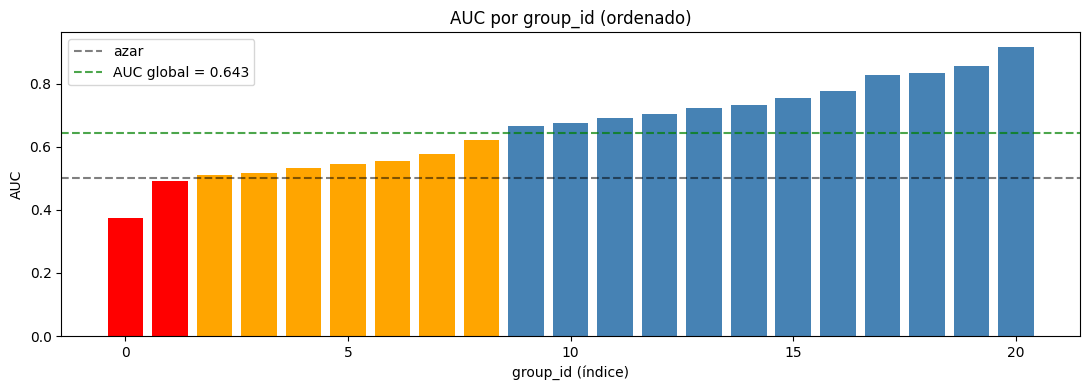


Group_ids con AUC < 0.5 (peor que azar): 2
Group_ids con AUC > 0.75 (buenos): 6

Varianza de AUC entre grupos: 0.1412
(Si es alta → hay grupos mucho más difíciles que otros)


In [ ]:
# Visualizar dispersión de AUC por group_id
metrics_group_valid = metrics_group.dropna(subset=["auc"])

if len(metrics_group_valid) > 0:
    plt.figure(figsize=(11, 4))
    sorted_aucs = metrics_group_valid.sort_values("auc")["auc"].values
    plt.bar(range(len(sorted_aucs)), sorted_aucs,
            color=["red" if a < 0.5 else "orange" if a < 0.65 else "steelblue" for a in sorted_aucs])
    plt.axhline(0.5, color="black", linestyle="--", alpha=0.5, label="azar")
    plt.axhline(auc_global, color="green", linestyle="--", alpha=0.7,
                label=f"AUC global = {auc_global:.3f}")
    plt.title("AUC por group_id (ordenado)")
    plt.xlabel("group_id (índice)")
    plt.ylabel("AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nGroup_ids con AUC < 0.5 (peor que azar): "
          f"{(metrics_group_valid['auc'] < 0.5).sum()}")
    print(f"Group_ids con AUC > 0.75 (buenos): "
          f"{(metrics_group_valid['auc'] > 0.75).sum()}")
    print(f"\nVarianza de AUC entre grupos: {metrics_group_valid['auc'].std():.4f}")
    print(f"(Si es alta → hay grupos mucho más difíciles que otros)")

In [ ]:
# Métricas por descripción (escenario textual)
metrics_scen = metrics_by_group(df_val, "description", min_samples=8)
print(f"Escenarios analizados: {len(metrics_scen)}")

if len(metrics_scen) > 0:
    print("\nTop 5 mejores escenarios:")
    display(metrics_scen.head(5))
    print("\nTop 5 peores escenarios:")
    display(metrics_scen.tail(5))

Escenarios analizados: 27

Top 5 mejores escenarios:


,description,n_samples,n_pos,n_neg,auc,ap,acc@0.5,f1@0.5,mean_score
0,a cyclist changes lines into motorway,9,4,5,1.0000,1.0000,0.7778,0.6667,0.4597
18,ego-car accelerately goes straight at non-sign...,10,4,6,1.0000,1.0000,0.9000,0.8889,0.4594
23,lead vehicle decelerates,8,4,4,0.9375,0.9500,0.6250,0.7273,0.6429
19,ego-car is out of control,10,4,6,0.9167,0.9167,0.6000,0.6667,0.6368
6,a motorbike runs red light,9,3,6,0.8333,0.8333,0.6667,0.6667,0.6544



Top 5 peores escenarios:


,description,n_samples,n_pos,n_neg,auc,ap,acc@0.5,f1@0.5,mean_score
11,a vehicle is out of control,34,14,20,0.4464,0.4778,0.6176,0.3810,0.3836
26,there is an object crash,8,3,5,0.4000,0.3873,0.3750,0.0000,0.4954
14,a vehicle turns right across path at non-signa...,9,4,5,0.4000,0.5683,0.4444,0.4444,0.5598
3,a motorbike changes lines into motorway,15,8,7,0.3214,0.4640,0.4000,0.4000,0.4917
25,there is an object crash,9,3,6,0.2222,0.2897,0.4444,0.2857,0.5269


## 5. Análisis 2 — Casos de alta y baja confianza

Los **FP con alta confianza** son los más informativos: el modelo está
muy seguro y se equivoca. Estos casos suelen revelar atajos espurios o
limitaciones de la formulación.

Los **TP con alta confianza** muestran qué tipo de patrones aprende bien.

Las **predicciones cercanas a 0.5** son casos donde el modelo no sabe;
si todos comparten algo, indica un tipo de input que la arquitectura no
puede resolver.

In [ ]:
def show_top_n(df, error_type, n=10, ascending=False, by="score"):
    """Muestra las top-N muestras de un tipo de error ordenadas por score."""
    subset = df[df["error_type"] == error_type].copy()
    subset = subset.sort_values(by, ascending=ascending)
    cols = ["video_id", "label", "pred", "score", "gap_to_toa",
            "is_absolute_negative", "description"]
    return subset.head(n)[cols]


print("=" * 65)
print("TP con score más alto (aciertos confiados en clase 1)")
print("=" * 65)
display(show_top_n(df_val, "TP", n=10, ascending=False))

print()
print("=" * 65)
print("FP con score más alto (errores MUY CONFIADOS — los más informativos)")
print("=" * 65)
display(show_top_n(df_val, "FP", n=10, ascending=False))

TP con score más alto (aciertos confiados en clase 1)


,video_id,label,pred,score,gap_to_toa,is_absolute_negative,description
102,11/209,1,1,0.8838,8,0,ego-car turns right across path at non-signal...
245,59/010,1,1,0.8794,6,0,a cyclist is out of control
594,11/130,1,1,0.8765,12,0,a vehicle turns left across path at non-signal...
407,61/005,1,1,0.8740,6,0,ego-car is out of control
208,5/139,1,1,0.8730,4,0,a motorbike crosses the road
647,48/051,1,1,0.8726,12,0,lead vehicle stops
735,5/078,1,1,0.8721,1,0,a motorbike crosses the road
59,6/068,1,1,0.8687,4,0,lead motorcycle stops
734,5/078,1,1,0.8662,17,0,a motorbike crosses the road
419,6/096,1,1,0.8643,12,0,a motorbike turns left across path at non-sign...



FP con score más alto (errores MUY CONFIADOS — los más informativos)


,video_id,label,pred,score,gap_to_toa,is_absolute_negative,description
69,43/090,0,1,0.8662,134,0,lead vehicle stops
194,11/107,0,1,0.8652,-1,1,a vehicle changes lanes with the same directio...
642,6/054,0,1,0.8643,64,0,ego-car turns left across path at non-signaliz...
91,6/038,0,1,0.8633,131,0,ego-car turns right across path at non-signal...
733,5/078,0,1,0.8628,81,0,a motorbike crosses the road
71,43/090,0,1,0.8628,118,0,lead vehicle stops
695,49/018,0,1,0.8599,-1,1,a vehicle changes lanes with the same directio...
84,49/035,0,1,0.8555,48,0,a vehicle changes lanes with the same directio...
696,49/018,0,1,0.8511,-1,1,a vehicle changes lanes with the same directio...
491,9/011,0,1,0.8491,134,0,a vehicle overtakes


In [ ]:
print("=" * 65)
print("FN con score más bajo (rechazos confiados de positivos)")
print("=" * 65)
display(show_top_n(df_val, "FN", n=10, ascending=True))

print()
print("=" * 65)
print("TN con score más bajo (rechazos confiados de negativos)")
print("=" * 65)
display(show_top_n(df_val, "TN", n=10, ascending=True))

FN con score más bajo (rechazos confiados de positivos)


,video_id,label,pred,score,gap_to_toa,is_absolute_negative,description
126,10/021,1,0,0.1647,8,0,a vehicle crosses the road
602,21/009,1,0,0.1851,11,0,a vehicle is out of control
556,10/107,1,0,0.1868,15,0,a vehicle crosses the road
627,41/014,1,0,0.1873,10,0,a vehicle is out of control
309,41/004,1,0,0.2008,4,0,a vehicle is out of control
480,50/013,1,0,0.2031,8,0,a motorbike changes lines into motorway
537,5/037,1,0,0.2103,18,0,a motorbike crosses the road
693,48/007,1,0,0.2112,11,0,a vehicle crosses the road
678,10/156,1,0,0.2128,12,0,a vehicle crosses the road
736,39/021,1,0,0.2134,6,0,a vehicle is out of control



TN con score más bajo (rechazos confiados de negativos)


,video_id,label,pred,score,gap_to_toa,is_absolute_negative,description
716,10/139,0,0,0.1521,111,0,a vehicle crosses the road
714,10/139,0,0,0.1575,175,0,a vehicle crosses the road
520,5/106,0,0,0.1619,99,0,a motorbike crosses the road
569,3/005,0,0,0.1711,160,0,a cyclist crosses the road
553,49/027,0,0,0.1738,131,0,a vehicle changes lanes with the same directio...
563,6/117,0,0,0.1761,175,0,a motorbike is out of control
40,12/042,0,0,0.1777,168,0,a vehicle changes lanes with the same directio...
127,10/021,0,0,0.1793,72,0,a vehicle crosses the road
56,11/043,0,0,0.1835,35,0,ego-car goes straight crossing paths at non-si...
294,10/051,0,0,0.1873,178,0,a vehicle changes lanes - same direction


In [ ]:
# Predicciones en zona de duda (score cerca de 0.5)
print("=" * 65)
print("Casos donde el modelo NO decide (score ∈ [0.45, 0.55])")
print("=" * 65)
borderline = df_val[(df_val["score"] >= 0.45) & (df_val["score"] <= 0.55)].copy()
print(f"Total casos borderline: {len(borderline)} ({100*len(borderline)/len(df_val):.1f}% del val set)")

if len(borderline) > 0:
    # Distribución por tipo de error
    print("\nDistribución de error_type en zona borderline:")
    display(borderline["error_type"].value_counts().to_frame("count"))

    # Distribución por label real
    print("\nDistribución por label real:")
    display(borderline["label"].value_counts().to_frame("count"))

    # Algunos ejemplos
    print("\nEjemplos:")
    cols = ["video_id", "label", "pred", "score", "gap_to_toa", "description"]
    display(borderline.sort_values("score").head(15)[cols])

Casos donde el modelo NO decide (score ∈ [0.45, 0.55])
Total casos borderline: 118 (15.6% del val set)

Distribución de error_type en zona borderline:


,count
error_type,
TN,39
FN,29
FP,28
TP,22



Distribución por label real:


,count
label,
0,67
1,51



Ejemplos:


,video_id,label,pred,score,gap_to_toa,description
181,11/243,0,0,0.4507,136,a vehicle changes lanes with the same directio...
137,57/038,1,0,0.4539,20,a cyclist changes lines into motorway
373,4/013,0,0,0.4539,106,ego-car turns left across path at non-signaliz...
300,50/131,1,0,0.4558,8,lead vehicle stops
458,56/027,0,0,0.4561,50,a pedestrian crosses the road
729,5/097,1,0,0.4563,18,a motorbike crosses the road
224,48/039,1,0,0.4575,12,lead vehicle stops
576,57/034,1,0,0.4578,5,a cyclist crosses the road
85,24/011,0,0,0.4585,112,a vehicle is out of control
269,61/016,0,0,0.4585,141,ego-car is out of control


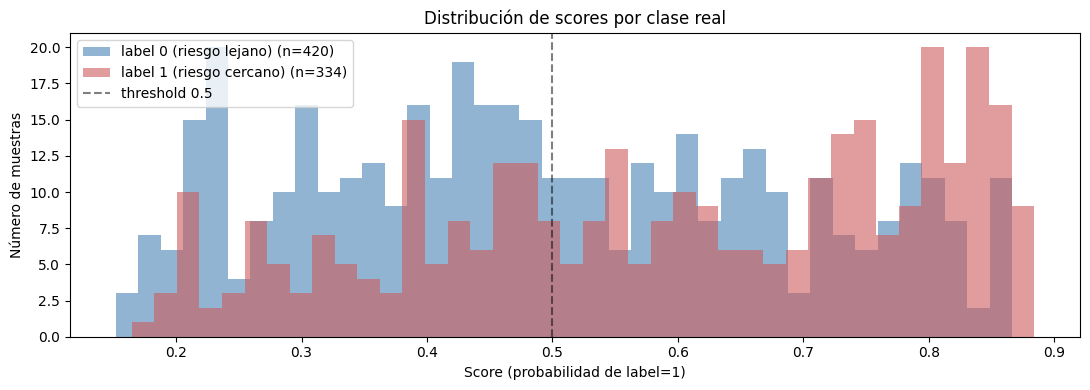


Estadísticas de score por clase:


,mean,std,min,max,median
label 0,0.4951,0.1903,0.1521,0.8662,0.4772
label 1,0.5949,0.1994,0.1647,0.8838,0.6116



Separación de medias (mean_pos - mean_neg): 0.0998
(Cuanto más alta, mejor está separando el modelo las clases)


In [ ]:
# Histograma de scores por clase
plt.figure(figsize=(11, 4))
for label, label_name, color in [(0, "label 0 (riesgo lejano)", "steelblue"),
                                   (1, "label 1 (riesgo cercano)", "indianred")]:
    subset = df_val[df_val["label"] == label]["score"]
    plt.hist(subset, bins=40, alpha=0.6, label=f"{label_name} (n={len(subset)})", color=color)
plt.axvline(0.5, linestyle="--", color="black", alpha=0.5, label="threshold 0.5")
plt.title("Distribución de scores por clase real")
plt.xlabel("Score (probabilidad de label=1)")
plt.ylabel("Número de muestras")
plt.legend()
plt.tight_layout()
plt.show()

# Estadísticas
print("\nEstadísticas de score por clase:")
score_stats = df_val.groupby("label")["score"].agg(["mean", "std", "min", "max", "median"]).round(4)
score_stats.index = ["label 0", "label 1"]
display(score_stats)

separation = score_stats.loc["label 1", "mean"] - score_stats.loc["label 0", "mean"]
print(f"\nSeparación de medias (mean_pos - mean_neg): {separation:.4f}")
print("(Cuanto más alta, mejor está separando el modelo las clases)")

## 6. Análisis 3 — Patrones de atención

¿El modelo distribuye su atención entre los subclips o solo se fija en uno?
Si la atención está siempre concentrada en el último subclip (más cercano al
TOA), el modelo no aprovecha la estructura temporal — solo mira lo más reciente.

Si la atención es uniforme, el modelo no decide qué subclip es más informativo.

Si difiere entre clases, el modelo está aprendiendo algo temporal real.

In [ ]:
S = attn_val.shape[1]
print(f"Número de subclips por muestra: {S}")

# Atención media global
mean_attn_global = attn_val.mean(axis=0)
print(f"\nAtención media global por subclip:")
for i, w in enumerate(mean_attn_global):
    print(f"  subclip {i}: {w:.4f}")

uniform = 1.0 / S
print(f"\nAtención uniforme sería: {uniform:.4f}")
print(f"Desviación de la uniformidad: {(mean_attn_global - uniform).std():.4f}")

# Entropía de la atención
entropy_global = -np.sum(mean_attn_global * np.log(mean_attn_global + 1e-8))
max_entropy = np.log(S)
print(f"\nEntropía global: {entropy_global:.4f} (máxima = {max_entropy:.4f})")
print(f"Ratio entropía / máxima: {entropy_global / max_entropy:.4f}")
print("(Cerca de 1 = atención uniforme, cerca de 0 = atención concentrada)")

Número de subclips por muestra: 3

Atención media global por subclip:
  subclip 0: 0.2885
  subclip 1: 0.3308
  subclip 2: 0.3807

Atención uniforme sería: 0.3333
Desviación de la uniformidad: 0.0377

Entropía global: 1.0922 (máxima = 1.0986)
Ratio entropía / máxima: 0.9942
(Cerca de 1 = atención uniforme, cerca de 0 = atención concentrada)


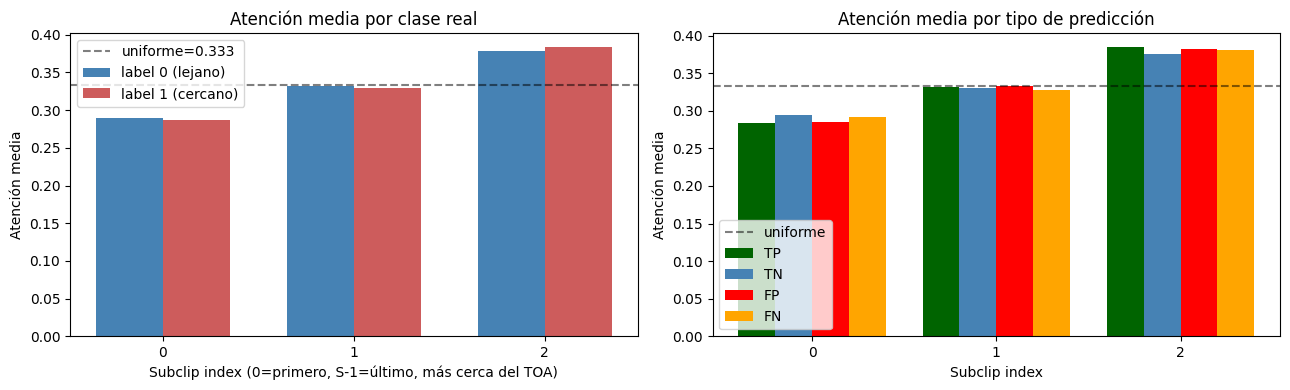

In [ ]:
# Atención por clase
mean_attn_pos = attn_val[df_val["label"].values == 1].mean(axis=0)
mean_attn_neg = attn_val[df_val["label"].values == 0].mean(axis=0)

# Atención por error_type
attn_by_err = {}
for err in ["TP", "TN", "FP", "FN"]:
    mask = df_val["error_type"].values == err
    if mask.sum() > 0:
        attn_by_err[err] = attn_val[mask].mean(axis=0)

# Plot atención por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = np.arange(S)
width = 0.35
ax.bar(x - width/2, mean_attn_neg, width, label="label 0 (lejano)", color="steelblue")
ax.bar(x + width/2, mean_attn_pos, width, label="label 1 (cercano)", color="indianred")
ax.axhline(uniform, linestyle="--", color="black", alpha=0.5,
           label=f"uniforme={uniform:.3f}")
ax.set_xlabel("Subclip index (0=primero, S-1=último, más cerca del TOA)")
ax.set_ylabel("Atención media")
ax.set_title("Atención media por clase real")
ax.set_xticks(x)
ax.legend()

# Plot atención por tipo de predicción
ax = axes[1]
colors = {"TP": "darkgreen", "TN": "steelblue", "FP": "red", "FN": "orange"}
width = 0.2
for i, (err, attn) in enumerate(attn_by_err.items()):
    ax.bar(x + (i - 1.5) * width, attn, width, label=err, color=colors.get(err))
ax.axhline(uniform, linestyle="--", color="black", alpha=0.5, label="uniforme")
ax.set_xlabel("Subclip index")
ax.set_ylabel("Atención media")
ax.set_title("Atención media por tipo de predicción")
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Pico de atención por muestra (¿en qué subclip se concentra?)
peaks = attn_val.argmax(axis=1)
df_val["attn_peak"] = peaks
df_val["attn_max_value"] = attn_val.max(axis=1)
df_val["attn_entropy"] = -np.sum(attn_val * np.log(attn_val + 1e-8), axis=1)

# Distribución de picos por clase
peak_dist = pd.crosstab(df_val["attn_peak"], df_val["label"], normalize="columns")
peak_dist.columns = ["label_0_far", "label_1_near"]
print("Distribución de subclip con MÁXIMA atención (% por clase):")
display((peak_dist * 100).round(2))

# Para evaluar: ¿hay diferencia clara en dónde mira el modelo entre clases?
chi2_test_data = pd.crosstab(df_val["attn_peak"], df_val["label"])
print(f"\nDistribución absoluta:")
display(chi2_test_data)

Distribución de subclip con MÁXIMA atención (% por clase):


,label_0_far,label_1_near
attn_peak,,
0,3.1000,3.8900
1,1.4300,2.1000
2,95.4800,94.0100



Distribución absoluta:


label,0,1
attn_peak,,
0,13,13
1,6,7
2,401,314


## 7. Análisis 4 — Rendimiento según gap al TOA

¿El modelo predice mejor cuando el accidente está más cerca o más lejos?
Esto te dice si la dificultad del problema escala con el horizonte de
anticipación.

Excluimos negativos absolutos (toa=0) porque su gap no tiene sentido temporal.

In [ ]:
# Solo muestras pre-TOA (toa > 0)
df_pre = df_val[~df_val["is_absolute_negative"].astype(bool)].copy()

# Bins de gap
gap_bins = [0, 5, 10, 20, 100, 130, 160, 200]
gap_labels = ["1-5", "6-10", "11-20", "21-100 (gris)", "101-130", "131-160", "161+"]
df_pre["gap_bin"] = pd.cut(df_pre["gap_to_toa"], bins=gap_bins, labels=gap_labels, right=True)

# Métricas por bin
rows = []
for bin_label in gap_labels:
    g = df_pre[df_pre["gap_bin"] == bin_label]
    if len(g) < 5:
        continue
    n_pos = int((g["label"] == 1).sum())
    n_neg = int((g["label"] == 0).sum())
    if n_pos > 0 and n_neg > 0:
        auc = roc_auc_score(g["label"], g["score"])
        ap = average_precision_score(g["label"], g["score"])
    else:
        auc = np.nan
        ap = np.nan

    rows.append({
        "gap_bin": bin_label,
        "n": len(g),
        "n_pos": n_pos,
        "n_neg": n_neg,
        "mean_score": g["score"].mean(),
        "auc": auc,
        "acc@0.5": accuracy_score(g["label"], g["pred"]),
    })

display(pd.DataFrame(rows))

,gap_bin,n,n_pos,n_neg,mean_score,auc,acc@0.5
0,1-5,73,73,0,0.6254,NaN,0.6712
1,6-10,93,93,0,0.5792,NaN,0.6022
2,11-20,168,168,0,0.5904,NaN,0.6667
3,21-100 (gris),88,0,88,0.4923,NaN,0.5909
4,101-130,170,0,170,0.4907,NaN,0.5471
5,131-160,106,0,106,0.4891,NaN,0.5566
6,161+,45,0,45,0.4849,NaN,0.5333


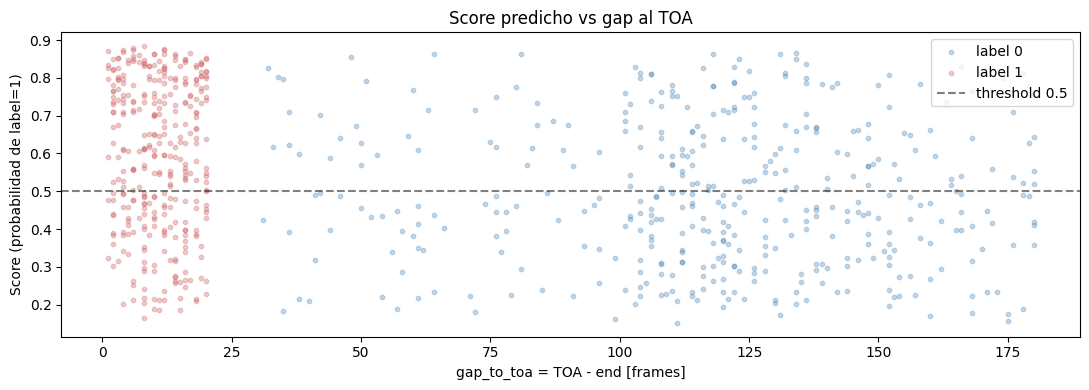

In [ ]:
# Score medio por gap (para muestras pre-TOA)
plt.figure(figsize=(11, 4))
plt.scatter(df_pre[df_pre["label"] == 0]["gap_to_toa"],
            df_pre[df_pre["label"] == 0]["score"],
            alpha=0.3, s=10, color="steelblue", label="label 0")
plt.scatter(df_pre[df_pre["label"] == 1]["gap_to_toa"],
            df_pre[df_pre["label"] == 1]["score"],
            alpha=0.3, s=10, color="indianred", label="label 1")
plt.axhline(0.5, linestyle="--", color="black", alpha=0.5, label="threshold 0.5")
plt.title("Score predicho vs gap al TOA")
plt.xlabel("gap_to_toa = TOA - end [frames]")
plt.ylabel("Score (probabilidad de label=1)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Exportar resultados

In [ ]:
# Exportar todo a CSV para revisión posterior
df_val.to_csv(OUTPUT_DIR / "val_predictions.csv", index=False)
metrics_group.to_csv(OUTPUT_DIR / "metrics_by_group.csv", index=False)
metrics_scen.to_csv(OUTPUT_DIR / "metrics_by_scenario.csv", index=False)

# Guardar atención
np.save(OUTPUT_DIR / "attention_weights.npy", attn_val)

print(f"Archivos exportados en {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  - {f.name}")

Archivos exportados en /data-fast/data-server/vlopezmo/model/error_analysis:
  - attention_weights.npy
  - metrics_by_group.csv
  - metrics_by_scenario.csv
  - val_predictions.csv


## 9. Conclusiones para el meeting con Albert

Hipótesis ordenadas según lo que el análisis cualitativo haya mostrado.
Ejecuta esta celda al final para tener el resumen automático listo para llevar.

In [ ]:
print("=" * 65)
print("RESUMEN DEL ANÁLISIS CUALITATIVO")
print("=" * 65)
print()
print(f"Modelo: {CHECKPOINT_PATH.name}")
print(f"Val AUC global: {auc_global:.4f}")
print(f"Val AP global:  {ap_global:.4f}")
print()

# 1. Heterogeneidad por escenario
print("1. HETEROGENEIDAD POR ESCENARIO")
if len(metrics_group_valid) > 0:
    print(f"   - AUC mediana por group_id: {metrics_group_valid['auc'].median():.4f}")
    print(f"   - AUC mínimo: {metrics_group_valid['auc'].min():.4f}")
    print(f"   - AUC máximo: {metrics_group_valid['auc'].max():.4f}")
    print(f"   - Std AUC entre grupos: {metrics_group_valid['auc'].std():.4f}")
    n_below_random = (metrics_group_valid['auc'] < 0.5).sum()
    print(f"   - Grupos con AUC < 0.5: {n_below_random}")
    if metrics_group_valid['auc'].std() > 0.10:
        print("   → Hay heterogeneidad significativa. Algunos escenarios son mucho más difíciles.")
    else:
        print("   → Heterogeneidad moderada o baja. El problema es uniforme.")
print()

# 2. Separación de scores
print("2. SEPARACIÓN DE SCORES POR CLASE")
print(f"   - Score medio label 0: {df_val[df_val['label']==0]['score'].mean():.4f}")
print(f"   - Score medio label 1: {df_val[df_val['label']==1]['score'].mean():.4f}")
print(f"   - Separación de medias: {separation:.4f}")
if separation < 0.05:
    print("   → Separación muy débil. El modelo apenas distingue las clases.")
elif separation < 0.10:
    print("   → Separación moderada. El modelo distingue pero con poco margen.")
else:
    print("   → Separación razonable.")
print()

# 3. Borderline
borderline_pct = 100 * len(borderline) / len(df_val)
print(f"3. CASOS BORDERLINE (score ∈ [0.45, 0.55])")
print(f"   - {len(borderline)} casos ({borderline_pct:.1f}% del val set)")
if borderline_pct > 30:
    print("   → Muchos casos donde el modelo no decide. Posible underfitting o tarea ambigua.")
else:
    print("   → Cantidad razonable. El modelo decide en la mayoría de casos.")
print()

# 4. Atención
print(f"4. PATRONES DE ATENCIÓN (S={S} subclips)")
print(f"   - Entropía / max: {entropy_global / max_entropy:.4f}")
if S == 2:
    print("   → Solo 2 subclips. Cualquier modelado temporal aporta poco.")
elif entropy_global / max_entropy > 0.95:
    print("   → Atención prácticamente uniforme. El modelo no decide qué subclip mira.")
elif entropy_global / max_entropy < 0.5:
    print("   → Atención muy concentrada. El modelo se fija en pocos subclips.")
else:
    print("   → Atención moderadamente diferenciada.")

# Diferencia entre clases
peak_diff = abs(mean_attn_pos - mean_attn_neg).max()
print(f"   - Máxima diferencia de atención entre clases: {peak_diff:.4f}")
if peak_diff < 0.02:
    print("   → El modelo mira lo MISMO en positivos y negativos. No usa estructura temporal.")
else:
    print("   → El modelo mira distinto según la clase. Usa la estructura temporal.")
print()

print("=" * 65)
print("PROPUESTAS PRIORIZADAS PARA EL MEETING")
print("=" * 65)
print()
print("Basándote en lo anterior, presenta estas opciones a Albert según")
print("lo que haya salido en cada análisis:")
print()
print("• Si hay alta heterogeneidad por escenario:")
print("   → El dataset tiene tipos de accidente intrínsecamente difíciles.")
print("     Considerar: análisis por tipo, posiblemente filtrar/estratificar.")
print()
print("• Si la separación de scores es débil:")
print("   → El problema es la formulación o la señal visual es genuinamente débil.")
print("     Considerar: reformular la tarea (etiquetar por centro), revisar splits.")
print()
print("• Si la atención es uniforme y/o S=2:")
print("   → Aumentar num_frames a 32 y subclip_stride a 2 → 10 subclips.")
print("     Esto da margen real a la modelación temporal.")
print()
print("• Si los FP con alta confianza tienen patrón visual común:")
print("   → El modelo aprendió un atajo. Mirar las imágenes e identificarlo.")

RESUMEN DEL ANÁLISIS CUALITATIVO

Modelo: x3ds_gru_v1_20260505_230847_16f_seed44_freezeBackbone1_unfreezeLast2_lrHead1e-04_lrBackbone3e-06_wd1e-03_aug1_dm64_gru1_bi1_do50_aucStop_cosine_wu3_mix1_last.pt
Val AUC global: 0.6435
Val AP global:  0.5979

1. HETEROGENEIDAD POR ESCENARIO
   - AUC mediana por group_id: 0.6750
   - AUC mínimo: 0.3750
   - AUC máximo: 0.9167
   - Std AUC entre grupos: 0.1412
   - Grupos con AUC < 0.5: 2
   → Hay heterogeneidad significativa. Algunos escenarios son mucho más difíciles.

2. SEPARACIÓN DE SCORES POR CLASE
   - Score medio label 0: 0.4951
   - Score medio label 1: 0.5949
   - Separación de medias: 0.0998
   → Separación moderada. El modelo distingue pero con poco margen.

3. CASOS BORDERLINE (score ∈ [0.45, 0.55])
   - 118 casos (15.6% del val set)
   → Cantidad razonable. El modelo decide en la mayoría de casos.

4. PATRONES DE ATENCIÓN (S=3 subclips)
   - Entropía / max: 0.9942
   → Atención prácticamente uniforme. El modelo no decide qué subclip 